# Ames Housing: Explaining the Model with SHAP

The EDA notebook explored the raw data. This notebook does the opposite end of
the project: it explains the *trained model*. Once a model can predict a price,
the natural next question is *why* it predicts what it does, and SHAP is the
standard tool for answering that.

SHAP (SHapley Additive exPlanations) attributes each prediction across the
features. For any house it can say the prediction started near the dataset
average and was then pushed up or down by each feature in turn. That works both
globally (which features matter across all houses) and locally (why one specific
prediction came out the way it did).

This notebook is the interactive companion to `explain_model.py`. The script
generates the charts as files; here you can poke around, explain different
houses, and look at different features.

**One note on units.** The model is trained on `log1p(price)`, so SHAP values
here are in log space, not dollars. They rank and compare features correctly,
but read them as relative pushes rather than dollar amounts.

## 1. Load the trained model and the data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# The saved XGBoost bundle and the featured data it was trained on.
bundle = joblib.load("models/best_model.pkl")
model = bundle["model"]
print("Model:", type(model).__name__)
print("Trained test RMSE: $%s" % f"{bundle['metadata']['test_rmse_dollars']:,.0f}")

df = pd.read_csv("data/processed/ames_featured.csv")
X = df.drop(columns=["SalePrice"])
X = X[list(model.feature_names_in_)]   # exact training columns, in order
y = df["SalePrice"]
print("Data:", X.shape[0], "houses,", X.shape[1], "features")

Model: XGBRegressor
Trained test RMSE: $22,836
Data: 2930 houses, 109 features


## 2. Compute SHAP values

For tree models like XGBoost, SHAP has a dedicated `TreeExplainer` that is exact
(not approximate) and fast. It computes SHAP values for all ~2,900 houses in
seconds.

In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
print("SHAP values computed:", shap_values.values.shape)
print("(one value per house per feature)")

SHAP values computed: (2930, 109)
(one value per house per feature)


## 3. Global view: what drives the model overall?

The beeswarm summary is SHAP's signature plot. Each dot is a house. Features are
ranked by importance top to bottom. A dot's horizontal position is how much that
feature moved that house's prediction, and the colour is the feature's value
(red high, blue low).

Reading it: for a feature where red dots sit on the right and blue on the left,
higher values push the price up. The wider a row spreads, the more that feature
swings predictions across houses.

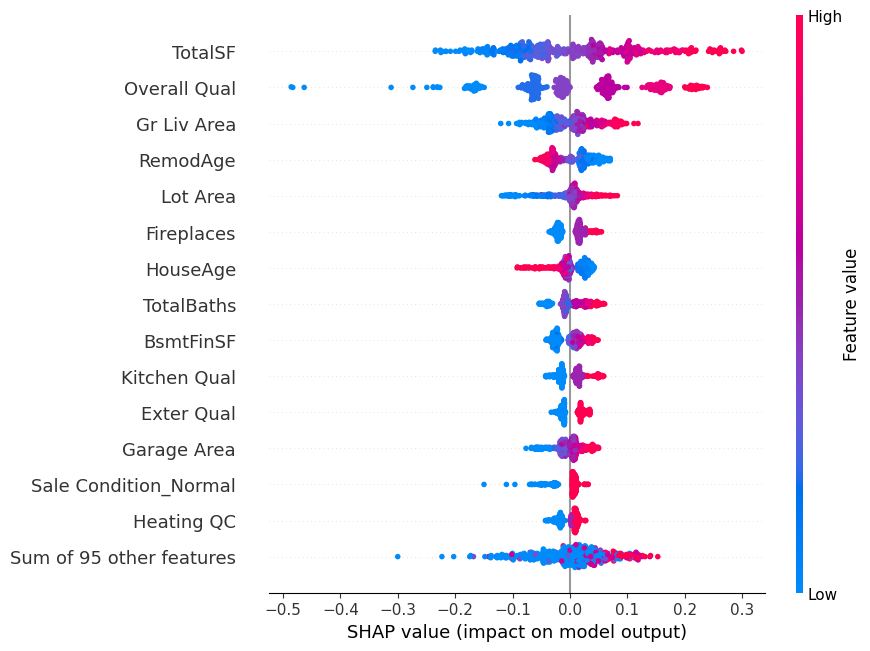

In [3]:
# Sample for readability (a few hundred dots is plenty).
idx = np.random.RandomState(42).choice(len(X), size=500, replace=False)
shap.plots.beeswarm(shap_values[idx], max_display=15)

A simpler version is the mean-importance bar plot: features ranked purely by how
much they move the prediction on average. This is the clean "what matters most"
ranking.

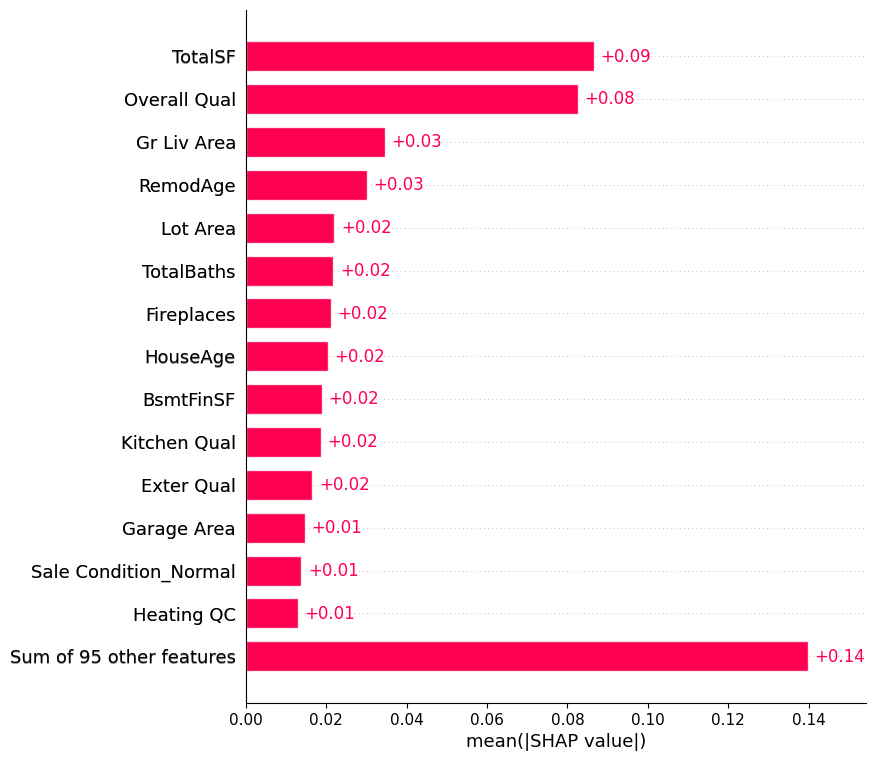

In [4]:
shap.plots.bar(shap_values, max_display=15)

In [5]:
# The same ranking as text.
importance = np.abs(shap_values.values).mean(axis=0)
ranking = pd.Series(importance, index=X.columns).sort_values(ascending=False)
print("Top 12 features by mean absolute SHAP value:\n")
print(ranking.head(12).round(4))

Top 12 features by mean absolute SHAP value:

TotalSF         0.0865
Overall Qual    0.0826
Gr Liv Area     0.0347
RemodAge        0.0301
Lot Area        0.0220
TotalBaths      0.0218
Fireplaces      0.0212
HouseAge        0.0204
BsmtFinSF       0.0189
Kitchen Qual    0.0187
Exter Qual      0.0166
Garage Area     0.0147
dtype: float32


Compare this ranking to the correlations from the EDA notebook. Quality and size
lead in both, which is reassuring. But SHAP reflects how the model *actually
uses* each feature, including interactions, so the order is not identical to the
raw correlations. The engineered `TotalSF` feature usually lands at or near the
top, which is direct evidence that combining the basement and floor areas into
one feature was worthwhile.

## 4. Local view: explain a single prediction

The real power of SHAP is explaining *one* prediction. The waterfall plot starts
from the average prediction and shows each feature pushing the value up (red) or
down (blue) to the final number for that specific house.

The cell below is written so you can change `house_index` to explain any house
you like. Try a few.

House 2067: predicted $160,629, actual $165,250


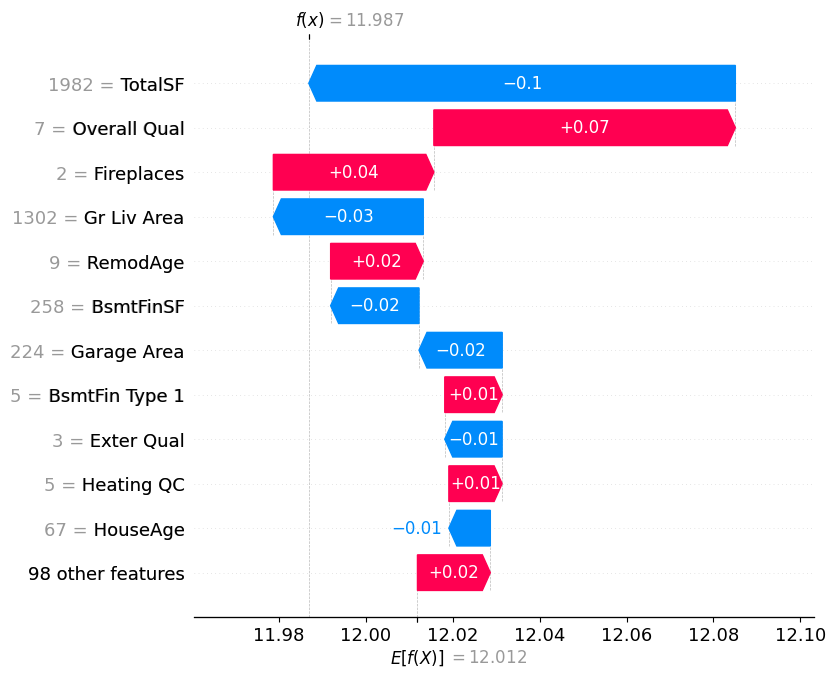

In [6]:
preds = np.expm1(model.predict(X))

# Change this to explore any house (0 to len(X)-1).
house_index = int(np.argmin(np.abs(preds - np.median(preds))))  # a typical house

print(f"House {house_index}: predicted ${preds[house_index]:,.0f}, "
      f"actual ${y.values[house_index]:,.0f}")
shap.plots.waterfall(shap_values[house_index], max_display=12)

Now a more interesting case: the house the model **under-predicted the most**.
Seeing which features failed to lift the prediction enough is exactly the kind
of diagnostic SHAP is good for.

Biggest under-prediction: house 1760
  predicted $538,254, actual $745,000, off by $206,746


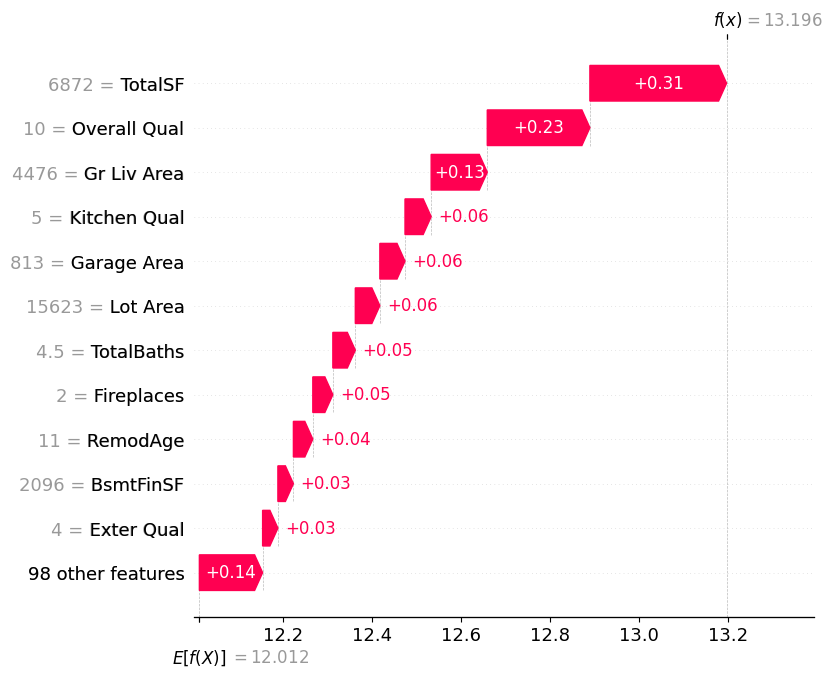

In [7]:
err = preds - y.values
worst_under = int(err.argmin())
print(f"Biggest under-prediction: house {worst_under}")
print(f"  predicted ${preds[worst_under]:,.0f}, actual ${y.values[worst_under]:,.0f}, "
      f"off by ${-err[worst_under]:,.0f}")
shap.plots.waterfall(shap_values[worst_under], max_display=12)

## 5. Dependence: how one feature's effect varies

A dependence plot takes a single feature and shows, across all houses, how its
value (x) relates to its SHAP contribution (y). It reveals whether the effect is
steady or changes across the range, and the vertical spread hints at
interactions with other features.

Here it is for the most important feature. Change `feature` to any column name to
explore others.

Dependence plot for: TotalSF


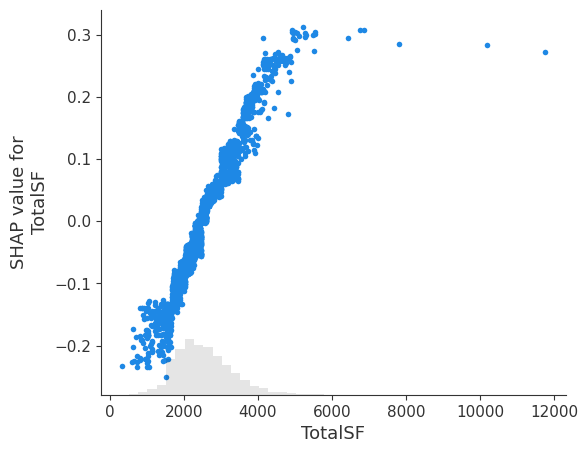

In [8]:
feature = ranking.index[0]  # the top feature; try "Overall Qual", "HouseAge", etc.
print(f"Dependence plot for: {feature}")
shap.plots.scatter(shap_values[:, feature])

## 6. Summary

SHAP turns the model from a black box into something you can interrogate:

* **Globally**, quality and size (especially the engineered `TotalSF`) dominate,
  which lines up with the EDA and confirms the feature engineering paid off.
* **Locally**, any single prediction can be broken down into the features that
  drove it, which is how you would justify a price to someone who asks.
* **Dependence** plots show how a feature's effect plays out across its range.

For a model that might inform real decisions, being able to explain predictions
this way matters as much as the accuracy itself. The reproducible version of
these charts is generated by `explain_model.py`.